In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from sklearn.utils import shuffle
import shutil
from skimage.transform import resize
from PIL import Image
from IPython.display import display

In [32]:
def get_stats(df, suffix=None):
    """Provides a quick summary of a dataframe."""
    try:
        print(f"DF shape: {df.shape}")
        print(f"# Patients: {df.empi_anon.nunique()}")
        print(f"# Exams: {df.acc_anon.nunique()}")
        print(f"# Images dicom: {df.anon_dicom_path.nunique()}\n")

    except Exception as e:
        print(e)


pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 500)


## Read clinical and metadata rows
DATA_ROOT = "/mnt/cv_data/shared_datasets/EMBED/tables"

magview_path = os.path.join(DATA_ROOT, "EMBED_OpenData_clinical_reduced.csv")
metadata_path = os.path.join(DATA_ROOT, "EMBED_OpenData_metadata_reduced.csv")

# Load metadata
df_clinical = pd.read_csv(magview_path)
df_metadata = pd.read_csv(metadata_path)

df_clinical["procdate_anon"] = pd.to_datetime(
    df_clinical["procdate_anon"], errors="coerce"
)

df_clinical["study_date_anon"] = pd.to_datetime(
    df_clinical["study_date_anon"], errors="coerce"
)
df_metadata["study_date_anon"] = pd.to_datetime(
    df_metadata["study_date_anon"], errors="coerce"
)

# df_metadata = df_metadata.sort_values(by=['study_date_anon']).reset_index(drop=True)
df_metadata = df_metadata.sort_values(by=["empi_anon", "study_date_anon"]).reset_index(
    drop=True
)
df_clinical = df_clinical.sort_values(by=["empi_anon", "study_date_anon"]).reset_index(
    drop=True
)

OUTPUT_ROOT = "/mnt/cv_data/users/mengxu/Longitudinal_Mammogram_Alignment/output_csv"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

df_metadata.to_csv(
    os.path.join(OUTPUT_ROOT, "EMBED_OpenData_metadata_reduced_sorted.csv"),
    index=False
)

df_clinical.to_csv(
    os.path.join(OUTPUT_ROOT, "EMBED_OpenData_clinical_reduced_sorted.csv"),
    index=False
)
print("clinical data input")
get_stats(df_clinical)
print("metadata data input")
get_stats(df_metadata)

display(df_metadata)
display(df_clinical)

/tmp/ipykernel_1246108/1621680290.py:24: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clinical = pd.read_csv(magview_path)
/tmp/ipykernel_1246108/1621680290.py:25: DtypeWarning: Columns (21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metadata = pd.read_csv(metadata_path)


clinical data input
DF shape: (81776, 21)
# Patients: 23253
# Exams: 72770
'DataFrame' object has no attribute 'anon_dicom_path'
metadata data input
DF shape: (480323, 23)
# Patients: 23256
# Exams: 72770
# Images dicom: 480323



,empi_anon,acc_anon,cohort_num,study_date_anon,StudyDescription,SeriesDescription,FinalImageType,ImageLateralityFinal,ViewPosition,spot_mag,anon_dicom_path,num_ROI,ROI_coords,Manufacturer,ManufacturerModelName,PatientSex,ProtocolName,SeriesNumber,SeriesTime,WindowCenter,WindowWidth,VOILUTFunction,WindowCenterWidthExplanation
0,10000879,6992096043050201,1,2018-02-16,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO,2D,R,MLO,NaN,images/cohort_1/10000879/1.2.842.113970.3.62.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R MLO ComboHD,71300000,101829.0,2047.0,4096.0,NaN,NaN
1,10000879,6992096043050201,1,2018-02-16,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L MLO,2D,L,MLO,NaN,images/cohort_1/10000879/1.2.842.113970.3.62.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,L MLO ComboHD,71300000,102019.0,2047.0,4096.0,NaN,NaN
2,10000879,6992096043050201,1,2018-02-16,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC,2D,R,CC,NaN,images/cohort_1/10000879/1.2.842.113970.3.62.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R CC ComboHD,71300000,101405.0,2047.0,4096.0,NaN,NaN
3,10000879,6992096043050201,1,2018-02-16,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L MLO C-View,cview,L,MLO,NaN,images/cohort_1/10000879/1.2.842.113970.3.62.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,L MLO ComboHD,71300000,102019.0,540.0,580.0,NaN,NaN
4,10000879,6992096043050201,1,2018-02-16,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC C-View,cview,R,CC,NaN,images/cohort_1/10000879/1.2.842.113970.3.62.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R CC ComboHD,71300000,101405.0,540.0,580.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480318,99999564,4369225803558884,1,2017-04-25,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L MLO,2D,L,MLO,NaN,images/cohort_1/99999564/1.2.845.113971.3.61.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,L MLO Combo,71300000,135119.0,2047.0,4096.0,NaN,NaN
480319,99999564,8832872399780580,1,2019-02-27,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L CC,2D,L,CC,NaN,images/cohort_1/99999564/1.2.844.113972.3.66.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,L CC Combo,71300000,83056.0,2047.0,4096.0,NaN,NaN
480320,99999564,8832872399780580,1,2019-02-27,MG Screen Bilat w/Tomo/CAD Stnd Protocol,L MLO,2D,L,MLO,NaN,images/cohort_1/99999564/1.2.844.113972.3.66.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,L MLO Combo,71300000,83213.0,2047.0,4096.0,NaN,NaN
480321,99999564,8832872399780580,1,2019-02-27,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC,2D,R,CC,NaN,images/cohort_1/99999564/1.2.844.113972.3.66.1...,0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R CC Combo,71300000,82918.0,2047.0,4096.0,NaN,NaN


,Unnamed: 0,empi_anon,acc_anon,desc,numfind,side,asses,tissueden,bside,GENDER_DESC,RACE_DESC,ETHNIC_GROUP_DESC,MARITAL_STATUS_DESC,age_at_study,study_date_anon,procdate_anon,cohort_num,path_severity,total_L_find,total_R_find,first_3_zip
0,31489,10000879,6992096043050201,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,NaN,N,3.0,NaN,Female,Multiple,Not Recorded,Not Recorded,41.879026,2018-02-16,NaT,1,NaN,0.0,0.0,301.0
1,10198,10009146,4190527469809995,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,NaN,N,4.0,NaN,Female,"Unknown, Unavailable or Unreported","Unreported, Unknown, Unavailable",Not Recorded,38.924824,2014-07-04,NaT,1,NaN,0.0,0.0,303.0
2,20474,10015693,1334581155737139,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,L,A,2.0,NaN,Female,Caucasian or White,Non-Hispanic or Latino,Divorced,65.167663,2015-10-11,NaT,1,NaN,1.0,0.0,300
3,31427,10015693,2281263876413228,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,NaN,N,2.0,NaN,Female,Caucasian or White,Non-Hispanic or Latino,Divorced,67.407271,2018-01-06,NaT,1,NaN,0.0,0.0,300.0
4,42831,10019048,6465041439526495,MG Screening Bilateral,1,NaN,N,4.0,NaN,Female,Native Hawaiian or Other Pacific Islander,Hispanic or Latino,Married,45.646386,2013-03-11,NaT,2,NaN,0.0,0.0,301.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81771,10363,99996622,5582628875236699,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,B,B,3.0,NaN,Female,African American or Black,Non-Hispanic or Latino,Divorced,77.288377,2014-07-24,NaT,1,NaN,1.0,2.0,303.0
81772,10364,99996622,5582628875236699,MG Screen Bilat w/Tomo/CAD Stnd Protocol,2,R,B,3.0,NaN,Female,African American or Black,Non-Hispanic or Latino,Divorced,77.288377,2014-07-24,NaT,1,NaN,1.0,2.0,303.0
81773,21119,99996622,9655172659462321,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,NaN,N,3.0,NaN,Female,African American or Black,Non-Hispanic or Latino,Divorced,79.152892,2016-06-04,NaT,1,NaN,0.0,0.0,303
81774,25708,99999564,4369225803558884,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,NaN,N,3.0,NaN,Female,Caucasian or White,Non-Hispanic or Latino,Married,73.573037,2017-04-25,NaT,1,NaN,0.0,0.0,300.0


In [33]:
# An image is labeled as "cancer" if it has an "asses" value (BIRADS score) of "K" 
# or a "path_severity" value (pathology result) of 0 or 1. 
# This means that any image that meets either of these criteria will be included in the "cancer_images" dataframe.
cancer_images = df_clinical[
    (df_clinical["asses"] == "K") | (df_clinical["path_severity"].isin([0, 1]))
]

output_path = os.path.join(OUTPUT_ROOT, "POSITIVE_GROUP_cancer_img.csv")

cancer_images.to_csv(output_path, index=False)

get_stats(cancer_images)
display(cancer_images)

DF shape: (1906, 21)
# Patients: 763
# Exams: 1200
'DataFrame' object has no attribute 'anon_dicom_path'


,Unnamed: 0,empi_anon,acc_anon,desc,numfind,side,asses,tissueden,bside,GENDER_DESC,RACE_DESC,ETHNIC_GROUP_DESC,MARITAL_STATUS_DESC,age_at_study,study_date_anon,procdate_anon,cohort_num,path_severity,total_L_find,total_R_find,first_3_zip
60,61749,10065686,8381398024560613,MG Diagnostic Bilateral w/ CAD,1,R,K,3.0,NaN,Female,Asian,Non-Hispanic or Latino,Not Recorded,57.090837,2016-09-28,NaT,2,NaN,1.0,1.0,300.0
111,44090,10119504,5579010047669510,MG Diagnostic Mammo Bilateral,1,L,S,2.0,L,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,72.201346,2013-01-19,2013-01-20,2,0.0,1.0,0.0,303.0
112,44089,10119504,9436120411494617,MG Diagnostic Left,1,L,K,2.0,NaN,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,72.642149,2013-06-29,NaT,2,NaN,1.0,0.0,303.0
113,49206,10119504,9897073854156802,MG Diagnostic Mammo Bilateral,1,L,K,2.0,NaN,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,73.260916,2014-02-10,NaT,2,NaN,1.0,0.0,303.0
169,71140,10173804,7180728150657133,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,L,A,3.0,L,Female,Caucasian or White,Non-Hispanic or Latino,Married,72.888560,2018-08-05,2018-11-10,2,0.0,3.0,0.0,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81609,81669,99761210,5735953033883954,MG Diagnostic Bilateral w/Tomo/CAD,1,L,A,3.0,L,Female,Caucasian or White,Hispanic or Latino,Married,53.572626,2020-03-14,2020-03-28,2,1.0,2.0,1.0,303.0
81610,81670,99761210,5735953033883954,MG Diagnostic Bilateral w/Tomo/CAD,2,L,A,3.0,L,Female,Caucasian or White,Hispanic or Latino,Married,53.572626,2020-03-14,2020-03-28,2,1.0,2.0,1.0,303.0
81670,57072,99859914,8060289603969136,MG Diagnostic Bilateral w/ CAD,2,L,S,3.0,L,Female,African American or Black,Non-Hispanic or Latino,Single,56.740385,2017-03-19,2017-03-22,2,1.0,2.0,0.0,301.0
81680,12449,99868531,9090933158477514,MG Diagnostic Right w/CAD,1,R,S,2.0,R,Female,African American or Black,Non-Hispanic or Latino,Married,66.235446,2015-06-21,2015-06-28,1,1.0,0.0,2.0,303.0


In [ ]:
# Ensure the dates are in datetime format
cancer_df = cancer_images.copy()
cancer_df["study_date_anon"] = pd.to_datetime(cancer_df["study_date_anon"])

# Step 1: Find the latest cancer diagnosis date for each patient
latest_diagnosis_dates = (
    cancer_df.groupby("empi_anon")["study_date_anon"]
    .max()
    .reset_index()
    .rename(columns={"study_date_anon": "latest_diagnosed_date"})
)

# Step 2: Merge the latest diagnosis dates back into the cancer dataframe
cancer_df = cancer_df.merge(latest_diagnosis_dates, on="empi_anon", how="left")

display(cancer_df)
print(cancer_df.columns)

,Unnamed: 0,empi_anon,acc_anon,desc,numfind,side,asses,tissueden,bside,GENDER_DESC,RACE_DESC,ETHNIC_GROUP_DESC,MARITAL_STATUS_DESC,age_at_study,study_date_anon,procdate_anon,cohort_num,path_severity,total_L_find,total_R_find,first_3_zip,latest_diagnosed_date
0,61749,10065686,8381398024560613,MG Diagnostic Bilateral w/ CAD,1,R,K,3.0,NaN,Female,Asian,Non-Hispanic or Latino,Not Recorded,57.090837,2016-09-28,NaT,2,NaN,1.0,1.0,300.0,2016-09-28
1,44090,10119504,5579010047669510,MG Diagnostic Mammo Bilateral,1,L,S,2.0,L,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,72.201346,2013-01-19,2013-01-20,2,0.0,1.0,0.0,303.0,2014-02-10
2,44089,10119504,9436120411494617,MG Diagnostic Left,1,L,K,2.0,NaN,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,72.642149,2013-06-29,NaT,2,NaN,1.0,0.0,303.0,2014-02-10
3,49206,10119504,9897073854156802,MG Diagnostic Mammo Bilateral,1,L,K,2.0,NaN,Female,"Unknown, Unavailable or Unreported",Hispanic or Latino,Divorced,73.260916,2014-02-10,NaT,2,NaN,1.0,0.0,303.0,2014-02-10
4,71140,10173804,7180728150657133,MG Screen Bilat w/Tomo/CAD Stnd Protocol,1,L,A,3.0,L,Female,Caucasian or White,Non-Hispanic or Latino,Married,72.888560,2018-08-05,2018-11-10,2,0.0,3.0,0.0,300.0,2019-09-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1901,81669,99761210,5735953033883954,MG Diagnostic Bilateral w/Tomo/CAD,1,L,A,3.0,L,Female,Caucasian or White,Hispanic or Latino,Married,53.572626,2020-03-14,2020-03-28,2,1.0,2.0,1.0,303.0,2020-03-14
1902,81670,99761210,5735953033883954,MG Diagnostic Bilateral w/Tomo/CAD,2,L,A,3.0,L,Female,Caucasian or White,Hispanic or Latino,Married,53.572626,2020-03-14,2020-03-28,2,1.0,2.0,1.0,303.0,2020-03-14
1903,57072,99859914,8060289603969136,MG Diagnostic Bilateral w/ CAD,2,L,S,3.0,L,Female,African American or Black,Non-Hispanic or Latino,Single,56.740385,2017-03-19,2017-03-22,2,1.0,2.0,0.0,301.0,2017-03-19
1904,12449,99868531,9090933158477514,MG Diagnostic Right w/CAD,1,R,S,2.0,R,Female,African American or Black,Non-Hispanic or Latino,Married,66.235446,2015-06-21,2015-06-28,1,1.0,0.0,2.0,303.0,2019-06-07


Index(['Unnamed: 0', 'empi_anon', 'acc_anon', 'desc', 'numfind', 'side',
       'asses', 'tissueden', 'bside', 'GENDER_DESC', 'RACE_DESC',
       'ETHNIC_GROUP_DESC', 'MARITAL_STATUS_DESC', 'age_at_study',
       'study_date_anon', 'procdate_anon', 'cohort_num', 'path_severity',
       'total_L_find', 'total_R_find', 'first_3_zip', 'latest_diagnosed_date'],
      dtype='object')


In [35]:
# Ensure that the dates are in datetime format
cancer_df = cancer_df.copy()
screenings_df = df_metadata.copy()

# Keep tissueden from clinical table and merge it into metadata table
clinical_density = df_clinical[
    ["empi_anon", "acc_anon", "tissueden"]
].drop_duplicates()

screenings_df = df_metadata.merge(
    clinical_density,
    on=["empi_anon", "acc_anon"],
    how="left"
)

cancer_df.rename(columns={"study_date_anon": "diagnosed_date_anon"}, inplace=True)

cancer_df["diagnosed_date_anon"] = pd.to_datetime(cancer_df["diagnosed_date_anon"])
screenings_df["study_date_anon"] = pd.to_datetime(screenings_df["study_date_anon"])
cancer_df["latest_diagnosed_date"] = pd.to_datetime(cancer_df["latest_diagnosed_date"])


# test if merger was successful and if tissueden is correctly merged
print("screenings_df columns:")
print(screenings_df.columns)

print("Non-null tissueden in screenings_df:", screenings_df["tissueden"].notna().sum())
display(screenings_df[["empi_anon", "acc_anon", "study_date_anon", "tissueden"]].head())


# Initialize an empty list to store the filtered screenings
filtered_screenings_list = []

# Group cancer images by patient ID and laterality
for _, cancer_row in cancer_df.iterrows():
    patient_id = cancer_row["empi_anon"]
    laterality = cancer_row["side"]
    cancer_diag_date = cancer_row["diagnosed_date_anon"]
    latest_cancer_diag_date = cancer_row["latest_diagnosed_date"]

    # Filter screenings for the same patient and laterality, with earlier dates than cancer diagnosis
    patient_screenings = screenings_df[
        (screenings_df["empi_anon"] == patient_id)  # Match the patient
        & (screenings_df["ImageLateralityFinal"] == laterality)  # Match the laterality
        & (
            screenings_df["study_date_anon"] <= latest_cancer_diag_date
        )  # Study date should be earlier than cancer diagnosis
    ]

    # Add the cancer diagnosis date to the filtered screenings
    if not patient_screenings.empty:
        patient_screenings = (
            patient_screenings.copy()
        )  # Make a copy to avoid SettingWithCopyWarning
        patient_screenings["diagnosed_date_anon"] = latest_cancer_diag_date

        # Append the updated screenings to the list
        filtered_screenings_list.append(patient_screenings)

# Concatenate all the results into a final DataFrame
final_filtered_screenings = pd.concat(filtered_screenings_list, ignore_index=True)

# Reset index and display the filtered DataFrame
final_filtered_screenings = final_filtered_screenings.reset_index(drop=True)

# Optionally, you can add a label for cancer images in the final result
final_filtered_screenings["Label"] = "Non-Cancer"
cancer_df["Label"] = "Cancer"

# Concatenate the cancer images with the filtered screenings
final_combined_df = pd.concat([cancer_df, final_filtered_screenings], ignore_index=True)

# Reset index for clarity
# final_combined_df = final_combined_df.reset_index(drop=True)
# Update the Label to 'Cancer' if diagnosed_date_anon equals study_date_anon
final_combined_df.loc[
    final_combined_df["diagnosed_date_anon"] == final_combined_df["study_date_anon"],
    "Label",
] = "Cancer"

# Identify patients with multiple exams
patients_with_multiple_exams = final_combined_df.groupby("empi_anon")[
    "acc_anon"
].nunique()

# Keep only patients with more than one previous examination
patients_with_multiple_exams = patients_with_multiple_exams[
    patients_with_multiple_exams > 1
].index

# Filter the DataFrame for these patients
filtered_images = final_combined_df[
    final_combined_df["empi_anon"].isin(patients_with_multiple_exams)
]
included_positions = ["CC", "MLO"]
filtered_images = filtered_images[
    filtered_images["ViewPosition"].isin(included_positions)
]
# Reset the index for consistency
filtered_images = filtered_images.reset_index(drop=True)


# Reset index if needed
filtered_images = filtered_images.drop_duplicates(
    subset=["anon_dicom_path"], keep="first"
)

get_stats(filtered_images)
display(filtered_images)

screenings_df columns:
Index(['empi_anon', 'acc_anon', 'cohort_num', 'study_date_anon',
       'StudyDescription', 'SeriesDescription', 'FinalImageType',
       'ImageLateralityFinal', 'ViewPosition', 'spot_mag', 'anon_dicom_path',
       'num_ROI', 'ROI_coords', 'Manufacturer', 'ManufacturerModelName',
       'PatientSex', 'ProtocolName', 'SeriesNumber', 'SeriesTime',
       'WindowCenter', 'WindowWidth', 'VOILUTFunction',
       'WindowCenterWidthExplanation', 'tissueden'],
      dtype='object')
Non-null tissueden in screenings_df: 477590


,empi_anon,acc_anon,study_date_anon,tissueden
0,10000879,6992096043050201,2018-02-16,3.0
1,10000879,6992096043050201,2018-02-16,3.0
2,10000879,6992096043050201,2018-02-16,3.0
3,10000879,6992096043050201,2018-02-16,3.0
4,10000879,6992096043050201,2018-02-16,3.0


DF shape: (5618, 43)
# Patients: 470
# Exams: 1734
# Images dicom: 5618



,Unnamed: 0,empi_anon,acc_anon,desc,numfind,side,asses,tissueden,bside,GENDER_DESC,RACE_DESC,ETHNIC_GROUP_DESC,MARITAL_STATUS_DESC,age_at_study,diagnosed_date_anon,procdate_anon,cohort_num,path_severity,total_L_find,total_R_find,first_3_zip,latest_diagnosed_date,Label,study_date_anon,StudyDescription,SeriesDescription,FinalImageType,ImageLateralityFinal,ViewPosition,spot_mag,anon_dicom_path,num_ROI,ROI_coords,Manufacturer,ManufacturerModelName,PatientSex,ProtocolName,SeriesNumber,SeriesTime,WindowCenter,WindowWidth,VOILUTFunction,WindowCenterWidthExplanation
0,NaN,10119504,5579010047669510,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-10,NaT,2,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L CC,2D,L,CC,NaN,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,LCC,71100000.0,85949.0,2047.0,4096.0,NaN,NaN
1,NaN,10119504,5579010047669510,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-10,NaT,2,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,NaN,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,LMLO,71100000.0,90443.0,2047.0,4096.0,NaN,NaN
2,NaN,10119504,5579010047669510,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-10,NaT,2,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L CC,2D,L,CC,1.0,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,LMCC,71100000.0,91253.0,2047.0,4096.0,NaN,NaN
3,NaN,10119504,5579010047669510,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-10,NaT,2,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,NaN,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,LMLO,71100000.0,90312.0,2047.0,4096.0,NaN,NaN
4,NaN,10119504,9436120411494617,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-10,NaT,2,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2013-06-29,MG Diagnostic Left,L CC,2D,L,CC,NaN,images/cohort_2/10119504/1.2.847.113977.3.61.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,LCC,71100000.0,141139.0,2047.0,4096.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17223,NaN,99868531,8969515521433877,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-07,NaT,1,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC,2D,R,CC,NaN,images/cohort_1/99868531/1.2.849.113975.3.63.1...,1.0,"[[2503, 2743, 2872, 3192]]","HOLOGIC, Inc.",Selenia Dimensions,F,R CC ComboHD,71300000.0,90627.0,2047.0,4096.0,NaN,NaN
17224,NaN,99868531,8969515521433877,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-07,NaT,1,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO C-View,cview,R,MLO,NaN,images/cohort_1/99868531/1.2.849.113975.3.63.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R MLO ComboHD,71300000.0,91049.0,540.0,580.0,NaN,NaN
17225,NaN,99868531,8969515521433877,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-07,NaT,1,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO,2D,R,MLO,NaN,images/cohort_1/99868531/1.2.849.113975.3.63.1...,1.0,"[[2114, 2602, 2411, 3141]]","HOLOGIC, Inc.",Selenia Dimensions,F,R MLO ComboHD,71300000.0,91049.0,2047.0,4096.0,NaN,NaN
17226,NaN,99868531,8969515521433877,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-07,NaT,1,NaN,NaN,NaN,NaN,NaT,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC C-View,cview,R,CC,NaN,images/cohort_1/99868531/1.2.849.113975.3.63.1...,0.0,[],"HOLOGIC, Inc.",Selenia Dimensions,F,R CC ComboHD,71300000.0,90627.0,540.0,580.0,NaN,NaN


In [36]:
filtered_images_final = filtered_images.copy()
filtered_images_final = filtered_images_final[
    ~filtered_images_final["ProtocolName"].str.contains(
        "SCC|SMLO|CCRL|CCID|MLOID|MLOIMF|MCC|MLOAC|CCAC|MLOIDIMF|MLONP|CCNP|MLOAX|MLOAXIMF|TAN|CCRM|CCAX|CEDM|CESM",
        case=False,
        na=False,
    )
]

filtered_images_final = filtered_images_final.drop(
    [
        "latest_diagnosed_date",
        "cohort_num",
        "Unnamed: 0",
        "PatientSex",
        "MARITAL_STATUS_DESC",
        "RACE_DESC",
        "GENDER_DESC",
        "desc",
        "first_3_zip",
        # "SRC_DST",
        "spot_mag",
        "ManufacturerModelName",
        "SeriesNumber",
        "SeriesTime",
        # "match_level",
        "ETHNIC_GROUP_DESC",
        "age_at_study",
    ],
    axis=1,
)

output_path = os.path.join(OUTPUT_ROOT, "POSITIVE_GROUP_with_screenings_NEW_2D_CView.csv") 

filtered_images_final.to_csv(output_path, index=False)

display(filtered_images_final)
get_stats(filtered_images_final)

,empi_anon,acc_anon,numfind,side,asses,tissueden,bside,diagnosed_date_anon,procdate_anon,path_severity,total_L_find,total_R_find,Label,study_date_anon,StudyDescription,SeriesDescription,FinalImageType,ImageLateralityFinal,ViewPosition,anon_dicom_path,num_ROI,ROI_coords,Manufacturer,ProtocolName,WindowCenter,WindowWidth,VOILUTFunction,WindowCenterWidthExplanation
0,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L CC,2D,L,CC,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN
1,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN
3,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN
4,10119504,9436120411494617,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-06-29,MG Diagnostic Left,L CC,2D,L,CC,images/cohort_2/10119504/1.2.847.113977.3.61.1...,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN
5,10119504,9436120411494617,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-06-29,MG Diagnostic Left,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.847.113977.3.61.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17222,99868531,6018116494364687,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2018-03-19,MG Diagnostic Bilateral w/ CAD,R MLO,2D,R,MLO,images/cohort_1/99868531/1.2.847.113979.3.63.1...,0.0,[],"HOLOGIC, Inc.",R MLO,2047.0,4096.0,NaN,NaN
17223,99868531,8969515521433877,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R CC,2D,R,CC,images/cohort_1/99868531/1.2.849.113975.3.63.1...,1.0,"[[2503, 2743, 2872, 3192]]","HOLOGIC, Inc.",R CC ComboHD,2047.0,4096.0,NaN,NaN
17224,99868531,8969515521433877,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO C-View,cview,R,MLO,images/cohort_1/99868531/1.2.849.113975.3.63.1...,0.0,[],"HOLOGIC, Inc.",R MLO ComboHD,540.0,580.0,NaN,NaN
17225,99868531,8969515521433877,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO,2D,R,MLO,images/cohort_1/99868531/1.2.849.113975.3.63.1...,1.0,"[[2114, 2602, 2411, 3141]]","HOLOGIC, Inc.",R MLO ComboHD,2047.0,4096.0,NaN,NaN


DF shape: (4315, 28)
# Patients: 470
# Exams: 1473
# Images dicom: 4315



#   Calculate Time to Cancer for Each Image with a cancer diagnosis (calcualte it betweeen the cancer image and each corresponding previous image)

In [37]:
# Step 1: Ensure the dataframe is sorted for each patient

df_final_img_time_cancer = filtered_images_final.copy()
df_final_img_time_cancer = df_final_img_time_cancer.sort_values(by=["empi_anon"])
# Ensure both dates are in datetime format
df_final_img_time_cancer["diagnosed_date_anon"] = pd.to_datetime(
    df_final_img_time_cancer["diagnosed_date_anon"]
)
df_final_img_time_cancer["study_date_anon"] = pd.to_datetime(
    df_final_img_time_cancer["study_date_anon"]
)


# Extract the year components
df_final_img_time_cancer["diagnosed_date_anon_year"] = df_final_img_time_cancer[
    "diagnosed_date_anon"
].dt.year
df_final_img_time_cancer["study_date_year"] = df_final_img_time_cancer[
    "study_date_anon"
].dt.year

# Calculate Time to Cancer in years (difference between years only)
df_final_img_time_cancer["Time_to_Cancer_Years"] = (
    df_final_img_time_cancer["diagnosed_date_anon_year"]
    - df_final_img_time_cancer["study_date_year"]
)
df_final_img_time_cancer = df_final_img_time_cancer[
    df_final_img_time_cancer["Time_to_Cancer_Years"] <= 5
]
df_final_img_time_cancer = df_final_img_time_cancer[
    df_final_img_time_cancer["Time_to_Cancer_Years"] >= 0
]

df_final_img_time_cancer = df_final_img_time_cancer[
    df_final_img_time_cancer.FinalImageType == "2D"
].reset_index(drop=True)

# remove patients with only one examination
patients_with_multiple_exams = df_final_img_time_cancer.groupby("empi_anon")[
    "acc_anon"
].nunique()

# Filter out patients with only one examination
patients_with_multiple_exams = patients_with_multiple_exams[
    patients_with_multiple_exams > 1
]

# Now, filter the original dataframe to include only patients with multiple examinations
df_final_img_time_cancer = df_final_img_time_cancer[
    df_final_img_time_cancer["empi_anon"].isin(patients_with_multiple_exams.index)
]


# Step 2: Define groups based on time-to-cancer
def assign_group(row):
    if row["Label"] == "Cancer":
        return None  # Exclude cancer patients
    time = row["Time_to_Cancer_Years"]
    if 0 <= time <= 1:
        return "BC 1Y"
    elif 1 < time <= 2:
        return "BC 2Y"
    elif 2 < time <= 3:
        return "BC 3Y"
    elif 3 < time <= 4:
        return "BC 4Y"
    elif 4 < time <= 5:
        return "BC 5Y"


# Apply the function
df_final_img_time_cancer["time_to_cancer_group"] = df_final_img_time_cancer.apply(
    assign_group, axis=1
)

# Step 3: Summarize distribution
distribution = (
    df_final_img_time_cancer.groupby("time_to_cancer_group")
    .size()
    .reset_index(name="count")
)
df_final_img_time_cancer = df_final_img_time_cancer.sort_values(
    by=["empi_anon", "acc_anon", "ImageLateralityFinal"]
).reset_index(drop=True)

output_path = os.path.join(OUTPUT_ROOT, "POSITIVE_GROUP_with_screenings_time_to_cancer_NEW.csv") 

df_final_img_time_cancer.to_csv(output_path, index=False)

# Display results
print(distribution)

get_stats(df_final_img_time_cancer)
display(df_final_img_time_cancer)

  time_to_cancer_group  count
0                BC 1Y   1288
1                BC 2Y    474
2                BC 3Y    380
3                BC 4Y    230
4                BC 5Y    168
DF shape: (3133, 32)
# Patients: 381
# Exams: 1321
# Images dicom: 3133



,empi_anon,acc_anon,numfind,side,asses,tissueden,bside,diagnosed_date_anon,procdate_anon,path_severity,total_L_find,total_R_find,Label,study_date_anon,StudyDescription,SeriesDescription,FinalImageType,ImageLateralityFinal,ViewPosition,anon_dicom_path,num_ROI,ROI_coords,Manufacturer,ProtocolName,WindowCenter,WindowWidth,VOILUTFunction,WindowCenterWidthExplanation,diagnosed_date_anon_year,study_date_year,Time_to_Cancer_Years,time_to_cancer_group
0,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L CC,2D,L,CC,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y
1,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y
2,10119504,5579010047669510,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-01-19,MG Diagnostic Mammo Bilateral,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.846.113971.3.59.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y
3,10119504,9436120411494617,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-06-29,MG Diagnostic Left,L CC,2D,L,CC,images/cohort_2/10119504/1.2.847.113977.3.61.1...,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y
4,10119504,9436120411494617,NaN,NaN,NaN,2.0,NaN,2014-02-10,NaT,NaN,NaN,NaN,Non-Cancer,2013-06-29,MG Diagnostic Left,L MLO,2D,L,MLO,images/cohort_2/10119504/1.2.847.113977.3.61.1...,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3128,99868531,8969515521433877,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2019-04-01,MG Screen Bilat w/Tomo/CAD Stnd Protocol,R MLO,2D,R,MLO,images/cohort_1/99868531/1.2.849.113975.3.63.1...,1.0,"[[2114, 2602, 2411, 3141]]","HOLOGIC, Inc.",R MLO ComboHD,2047.0,4096.0,NaN,NaN,2019,2019,0,BC 1Y
3129,99868531,9090933158477514,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2015-06-21,MG Diagnostic Right w/CAD,R MLO,2D,R,MLO,images/cohort_1/99868531/1.2.840.113971.3.60.1...,0.0,[],"HOLOGIC, Inc.",R MLO,2047.0,4096.0,NaN,NaN,2019,2015,4,BC 4Y
3130,99868531,9090933158477514,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2015-06-21,MG Diagnostic Right w/CAD,R CC,2D,R,CC,images/cohort_1/99868531/1.2.840.113971.3.60.1...,0.0,[],"HOLOGIC, Inc.",R CC,2047.0,4096.0,NaN,NaN,2019,2015,4,BC 4Y
3131,99868531,9161828304530939,NaN,NaN,NaN,2.0,NaN,2019-06-07,NaT,NaN,NaN,NaN,Non-Cancer,2016-02-01,MG Diagnostic Bilateral w/ CAD,R MLO,2D,R,MLO,images/cohort_1/99868531/1.2.846.113976.3.66.1...,0.0,[],"HOLOGIC, Inc.",R MLO,2047.0,4096.0,NaN,NaN,2019,2016,3,BC 3Y


# Plot the Time-to-Cancer Label Distribution

time_to_cancer_group
BC 1Y    1288
BC 2Y     474
BC 3Y     380
BC 4Y     230
BC 5Y     168
Name: count, dtype: int64


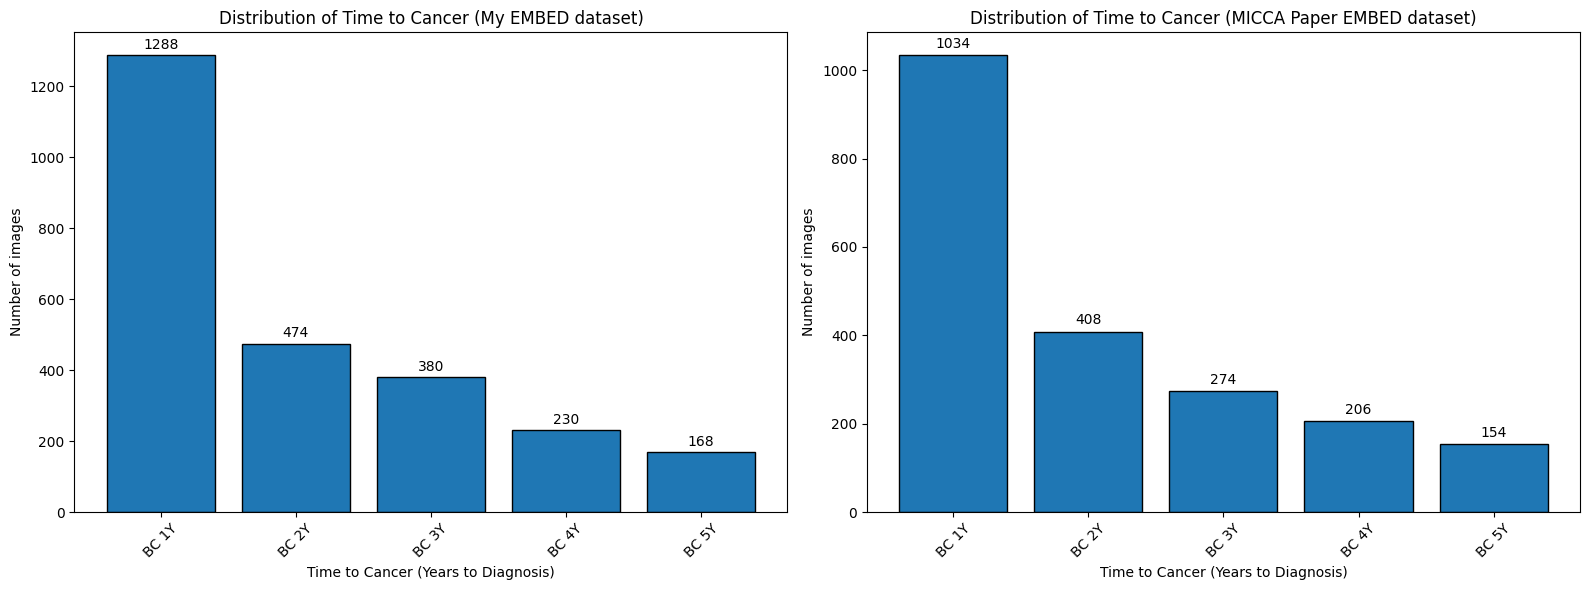

In [38]:
# Count the number of images in each bin
image_counts_per_bin = (
    df_final_img_time_cancer["time_to_cancer_group"].value_counts().sort_index()
)

# Print the counts for each bin
print(image_counts_per_bin)

# Values from the paper (for comparison)
values_paper = [1034, 408, 274, 206, 154]

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First plot (Bar plot for Time to Cancer from your dataset)
axes[0].bar(
    image_counts_per_bin.index.tolist(),
    image_counts_per_bin.values.tolist(),
    edgecolor="black",
)
axes[0].set_xlabel("Time to Cancer (Years to Diagnosis)")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Distribution of Time to Cancer (My EMBED dataset)")

# Add values above the bars for the first plot
for i, value in enumerate(image_counts_per_bin.values):
    axes[0].text(
        i, value + 10, str(value), ha="center", va="bottom", fontsize=10
    )  # Adjust the position as needed

# Second plot (Bar plot for Time to Cancer from 'values_paper')
axes[1].bar(
    ["BC 1Y", "BC 2Y", "BC 3Y", "BC 4Y", "BC 5Y"], values_paper, edgecolor="black"
)
axes[1].set_xlabel("Time to Cancer (Years to Diagnosis)")
axes[1].set_ylabel("Number of images")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Distribution of Time to Cancer (MICCA Paper EMBED dataset)")

# Add values above the bars for the second plot
for i, value in enumerate(values_paper):
    axes[1].text(
        i, value + 10, str(value), ha="center", va="bottom", fontsize=10
    )  # Adjust the position as needed

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plots
plt.show()

# fixing dicom file paths to the local ones.

In [39]:
EMBED_ROOT = "/mnt/cv_data/shared_datasets/EMBED"

def to_abs_dcm_path(p: str) -> str:
    # original p: "images/cohort_1/.../xxx.dcm"
    p = p.lstrip("/")  # remove leading slash if it exists
    return os.path.join(EMBED_ROOT, p) # Join the EMBED_ROOT with the relative path to get the absolute path

result_df_pos_group = df_final_img_time_cancer.copy()
result_df_pos_group["file_path_dcm"] = result_df_pos_group["anon_dicom_path"].apply(to_abs_dcm_path)

result_df_pos_group_final = result_df_pos_group.rename(
    columns={
        "empi_anon": "patient_id",
        "acc_anon": "exam_id",
        # "ImageLateralityFinall": "laterality", # The original code has a typo here so it keeps the original column name 
        "ViewPosition": "view",
        # "anon_dicom_path_local": "file_path_dcm", # The original code won't work here as no column is named 'anon_dicom_path_local'
        "tissueden": "density",
    }
)
result_df_pos_group_final = result_df_pos_group_final.drop(
    columns=[
        "anon_dicom_path",
        # "StudyID",
        "numfind",
        # "tissueden",
        "SeriesDescription",
        "asses",
        "path_severity",
        "bside",
        "side",
        "StudyDescription",
        "FinalImageType",
    ]
)

display(result_df_pos_group_final)

# This is the final csv file for the positive group. Only 2D images.
output_path = os.path.join(OUTPUT_ROOT, "POSITIVE_GROUP_FINAL.csv")
result_df_pos_group_final.to_csv(output_path, index=False)

print(result_df_pos_group_final["patient_id"].nunique())

,patient_id,exam_id,density,diagnosed_date_anon,procdate_anon,total_L_find,total_R_find,Label,study_date_anon,ImageLateralityFinal,view,num_ROI,ROI_coords,Manufacturer,ProtocolName,WindowCenter,WindowWidth,VOILUTFunction,WindowCenterWidthExplanation,diagnosed_date_anon_year,study_date_year,Time_to_Cancer_Years,time_to_cancer_group,file_path_dcm
0,10119504,5579010047669510,2.0,2014-02-10,NaT,NaN,NaN,Non-Cancer,2013-01-19,L,CC,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
1,10119504,5579010047669510,2.0,2014-02-10,NaT,NaN,NaN,Non-Cancer,2013-01-19,L,MLO,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
2,10119504,5579010047669510,2.0,2014-02-10,NaT,NaN,NaN,Non-Cancer,2013-01-19,L,MLO,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
3,10119504,9436120411494617,2.0,2014-02-10,NaT,NaN,NaN,Non-Cancer,2013-06-29,L,CC,0.0,[],"HOLOGIC, Inc.",LCC,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
4,10119504,9436120411494617,2.0,2014-02-10,NaT,NaN,NaN,Non-Cancer,2013-06-29,L,MLO,0.0,[],"HOLOGIC, Inc.",LMLO,2047.0,4096.0,NaN,NaN,2014,2013,1,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3128,99868531,8969515521433877,2.0,2019-06-07,NaT,NaN,NaN,Non-Cancer,2019-04-01,R,MLO,1.0,"[[2114, 2602, 2411, 3141]]","HOLOGIC, Inc.",R MLO ComboHD,2047.0,4096.0,NaN,NaN,2019,2019,0,BC 1Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
3129,99868531,9090933158477514,2.0,2019-06-07,NaT,NaN,NaN,Non-Cancer,2015-06-21,R,MLO,0.0,[],"HOLOGIC, Inc.",R MLO,2047.0,4096.0,NaN,NaN,2019,2015,4,BC 4Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
3130,99868531,9090933158477514,2.0,2019-06-07,NaT,NaN,NaN,Non-Cancer,2015-06-21,R,CC,0.0,[],"HOLOGIC, Inc.",R CC,2047.0,4096.0,NaN,NaN,2019,2015,4,BC 4Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...
3131,99868531,9161828304530939,2.0,2019-06-07,NaT,NaN,NaN,Non-Cancer,2016-02-01,R,MLO,0.0,[],"HOLOGIC, Inc.",R MLO,2047.0,4096.0,NaN,NaN,2019,2016,3,BC 3Y,/mnt/cv_data/shared_datasets/EMBED/images/coho...


381


In [40]:
# print missing values in density column in result_df_pos_group_final
print("Non-null density values in result_df_pos_group_final:", result_df_pos_group_final["density"].notna().sum())
print("Total rows in result_df_pos_group_final:", len(result_df_pos_group_final))

Non-null density values in result_df_pos_group_final: 3108
Total rows in result_df_pos_group_final: 3133


## The following code is to check, after including the density column, if a patient's density matches the original CSV

In [41]:
# test all patients in the final positive CSV

result_df_pos_group = pd.read_csv(os.path.join(OUTPUT_ROOT, "POSITIVE_GROUP_FINAL.csv"))
magview_full = pd.read_csv(os.path.join(DATA_ROOT, "EMBED_OpenData_clinical.csv"), dtype=str)

# print the total number of non-null density values in the final positive group 
print("Non-null density values in result_df_pos_group:", result_df_pos_group["density"].notna().sum())
print("Total rows in result_df_pos_group:", len(result_df_pos_group))

Non-null density values in result_df_pos_group: 3108
Total rows in result_df_pos_group: 3133


In [ ]:
# Check all patients in the final positive CSV

# Build exam-level clinical source table from magview_full
magview_exam = magview_full[
    ["empi_anon", "acc_anon", "study_date_anon", "tissueden"]
].copy()

magview_exam = magview_exam.rename(
    columns={
        "empi_anon": "patient_id",
        "acc_anon": "exam_id",
        "tissueden": "density_clinical"
    }
)

# Keep the requested columns from final positive CSV
result_exam = result_df_pos_group[
    ["patient_id", "exam_id", "density", "view", "file_path_dcm"]
].copy()

result_exam = result_exam.rename(columns={"density": "density_final"})

# Make merge keys consistent
magview_exam["patient_id"] = magview_exam["patient_id"].astype(str)
magview_exam["exam_id"] = magview_exam["exam_id"].astype(str)

result_exam["patient_id"] = result_exam["patient_id"].astype(str)
result_exam["exam_id"] = result_exam["exam_id"].astype(str)

# Drop duplicate exam-level rows in magview_full
magview_exam = magview_exam.drop_duplicates(
    subset=["patient_id", "exam_id", "study_date_anon", "density_clinical"]
)

# Drop duplicate rows in final result for the same image-level row set if needed
result_exam = result_exam.drop_duplicates()

# Merge: use final positive CSV as the main table
compare_df = pd.merge(
    result_exam,
    magview_exam,
    on=["patient_id", "exam_id"],
    how="left"
)

# Compare densities safely
compare_df["density_final_num"] = pd.to_numeric(compare_df["density_final"], errors="coerce")
compare_df["density_clinical_num"] = pd.to_numeric(compare_df["density_clinical"], errors="coerce")

compare_df["match"] = (
    (compare_df["density_final_num"] == compare_df["density_clinical_num"])
    |
    (compare_df["density_final_num"].isna() & compare_df["density_clinical_num"].isna())
)

# Keep only mismatched rows
mismatch_df = compare_df[~compare_df["match"]].copy()

# Display only the requested source/final columns plus match info
mismatch_df = mismatch_df[
    [
        "patient_id",        # from result_df_neg_group
        "exam_id",           # from result_df_neg_group
        "density_final",     # result_df_neg_group density
        "view",
        "file_path_dcm",
        "study_date_anon",   # from magview_full
        "density_clinical",  # magview_full tissueden
        "match"
    ]
]

print(f"Total rows in result_df_neg_group: {len(result_exam)}")
print(f"Total mismatched rows: {len(mismatch_df)}")

display(mismatch_df)

Total rows in result_df_neg_group: 3133
Total mismatched rows: 0


,patient_id,exam_id,density_final,view,file_path_dcm,study_date_anon,density_clinical,match
